# Aania — Cluster 1 stacking model

This cluster is highly imbalanced (with 1749 companies and only 8 of them are bankrupt companies), so the model may overfit easily. (0.46%)

## 1. Setup

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

Using same accuracy equation as C5

In [6]:
def eq1_accuracy(y_true, y_pred):
    TT = ((y_true == 1) & (y_pred == 1)).sum()
    TF = ((y_true == 1) & (y_pred == 0)).sum()
    return TT / (TT + TF) if (TT + TF) > 0 else 0.0

def show_confusion(y_true, y_pred, name):
    FF = ((y_true == 0) & (y_pred == 0)).sum()
    FT = ((y_true == 0) & (y_pred == 1)).sum()
    TT = ((y_true == 1) & (y_pred == 1)).sum()
    TF = ((y_true == 1) & (y_pred == 0)).sum()
    print(f'{name}:')
    print(f'  FF: {FF:>4}    FT: {FT:>4}')
    print(f'  TT: {TT:>4}    TF: {TF:>4}')
    print(f'  Eq.1 acc: {eq1_accuracy(y_true, y_pred):.4f}')
    return TT, TF

## 2. Load the cluster data

In [7]:
import os

df = pd.read_csv("../Clusters/cluster_1.csv")

print(f'Shape: {df.shape}')
print(f'Bankrupts: {df["Bankrupt?"].sum()} / {len(df)} ({df["Bankrupt?"].mean()*100:.2f}%)')

Shape: (1749, 98)
Bankrupts: 8 / 1749 (0.46%)


In [8]:
y = df['Bankrupt?'].values
X = df.drop(columns=['Bankrupt?', 'Index', 'Cluster'])

const_cols = [c for c in X.columns if X[c].nunique() <= 1]
print(f'Constant columns dropped: {const_cols}')
X = X.drop(columns=const_cols)
print(f'Features: {X.shape}')

Constant columns dropped: ['Liability-Assets Flag', 'Net Income Flag']
Features: (1749, 93)


Columns with only one unique value don’t help the model learn anything, so I removed them.

In [9]:
## Data Analysis

In [10]:
# Missing values check
missing = X.isnull().sum()
n_missing = (missing > 0).sum()
print(f'Columns with missing values: {n_missing}')
if n_missing > 0:
    print(missing[missing > 0])
else:
    print('No missing values - data is clean')

Columns with missing values: 0
No missing values - data is clean


In [11]:
# Duplicate rows check
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


In [12]:
# Constant columns - no predictive value, will be dropped before modeling
const_cols = [c for c in df.columns if df[c].nunique() == 1]
print(f'Constant columns ({len(const_cols)}):')
for c in const_cols:
    print(f'  - {c.strip()}')

Constant columns (3):
  - Liability-Assets Flag
  - Net Income Flag
  - Cluster


## 3. Feature selection with L1

Since this cluster is very small in terms of bankrupt examples, using too many features can easily lead to overfitting.

I did try different values of C and chose the one that keeps the no. of features small while still giving a good performance. 

In [13]:
X_scaled = StandardScaler().fit_transform(X)
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

print(f'{"C":>8} {"# features":>11} {"CV F1":>8}')
print('-' * 30)
for C in [0.005, 0.01, 0.02, 0.05, 0.1]:
    lr = LogisticRegression(penalty='l1', solver='saga', C=C,
                            class_weight='balanced', max_iter=5000,
                            random_state=RANDOM_STATE)
    lr.fit(X_scaled, y)
    n_feat = (lr.coef_[0] != 0).sum()
    f1 = cross_val_score(lr, X_scaled, y, cv=cv, scoring='f1').mean()
    print(f'{C:>8.3f} {n_feat:>11d} {f1:>8.4f}')

       C  # features    CV F1
------------------------------
   0.005           4   0.0467
   0.010           6   0.0533
   0.020          14   0.0661
   0.050          22   0.0921
   0.100          25   0.0637


Going with C=0.01 — gives ~6 features and the F1 doesn't really change between settings.

In [14]:
C_chosen = 0.01
selector = LogisticRegression(penalty='l1', solver='saga', C=C_chosen,
                              class_weight='balanced', max_iter=5000,
                              random_state=RANDOM_STATE)
selector.fit(X_scaled, y)

selected_features = X.columns[selector.coef_[0] != 0].tolist()
N_FEATURES = len(selected_features)
X_selected = X[selected_features]

print(f'Selected {N_FEATURES} features:\n')
for i, f in enumerate(selected_features, 1):
    coef = selector.coef_[0][list(X.columns).index(f)]
    print(f'  {i}. {f.strip():<55} coef={coef:+.3f}')

Selected 6 features:

  1. Tax rate (A)                                            coef=+0.008
  2. Borrowing dependency                                    coef=+0.178
  3. Average Collection Days                                 coef=+0.949
  4. Allocation rate per person                              coef=+0.216
  5. Cash Turnover Rate                                      coef=-0.486
  6. Net Income to Stockholder's Equity                      coef=-0.734


## 4. Three base models

The project requires at least 3 base models, so I used:

- Logistic Regression → simple and stable
- Random Forest → captures non-linear patterns
- Gradient Boosting → performs well on structured data


In [15]:
base_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=2000,
                               random_state=RANDOM_STATE))
])

base_rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                                  class_weight='balanced',
                                  random_state=RANDOM_STATE)

base_gb = GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                     learning_rate=0.05,
                                     random_state=RANDOM_STATE)

base_models = [('lr', base_lr), ('rf', base_rf), ('gb', base_gb)]

In [16]:
for name, model in base_models:
    f1 = cross_val_score(model, X_selected, y, cv=cv, scoring='f1').mean()
    print(f'{name}: CV F1 = {f1:.4f}')

lr: CV F1 = 0.0782
rf: CV F1 = 0.0000
gb: CV F1 = 0.0000


## 5. Stacking with cross-validation

Same structure as C5 — StackingClassifier with 5-fold CV inside it, LR meta-learner.

In [17]:
stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=2000,
                                       random_state=RANDOM_STATE),
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    stack_method='predict_proba',
)

stacking.fit(X_selected, y)
print('stacking model fitted')

stacking model fitted


## 6. Threshold tuning

The default threshold is 0.5, but in imbalanced data this can miss many bankrupt companies.

So I tried different thresholds and selected the one that maximizes Eq.1 accuracy.

Since the number of bankrupt cases is very small, even small changes in threshold can affect results significantly.

In [18]:
oof_proba = cross_val_predict(stacking, X_selected, y, cv=cv,
                              method='predict_proba')[:, 1]

print(f'{"thresh":>8} {"pred%":>8} {"TT":>4} {"TF":>4} {"Eq.1":>8}')
print('-' * 40)

best_thresh = 0.5
best_acc = 0.0
for t in np.arange(0.20, 0.85, 0.05):
    preds = (oof_proba >= t).astype(int)
    pred_rate = preds.mean()
    TT = ((y == 1) & (preds == 1)).sum()
    TF = ((y == 1) & (preds == 0)).sum()
    acc = eq1_accuracy(y, preds)
    flag = ' *' if (acc > best_acc and pred_rate < 0.10) else ''
    print(f'{t:>8.2f} {pred_rate*100:>7.2f}% {TT:>4} {TF:>4} {acc:>8.4f}{flag}')
    if acc > best_acc and pred_rate < 0.10:
        best_acc = acc
        best_thresh = t

print(f'\nPicked threshold: {best_thresh:.2f}  (CV Eq.1 acc {best_acc:.4f})')

  thresh    pred%   TT   TF     Eq.1
----------------------------------------
    0.20   31.56%    7    1   0.8750
    0.25   14.35%    6    2   0.7500
    0.30   11.72%    6    2   0.7500
    0.35   10.12%    5    3   0.6250
    0.40    9.43%    5    3   0.6250 *
    0.45    8.81%    5    3   0.6250
    0.50    7.89%    5    3   0.6250
    0.55    7.20%    5    3   0.6250
    0.60    6.63%    5    3   0.6250
    0.65    6.35%    5    3   0.6250
    0.70    5.72%    5    3   0.6250
    0.75    5.49%    5    3   0.6250
    0.80    5.09%    5    3   0.6250

Picked threshold: 0.40  (CV Eq.1 acc 0.6250)


Because the number of bankrupt examples is very low, the model may be sensitive to small changes in data.

So while the training results may look strong, they may not fully reflect real performance.

## 7. Save model bundle

In [19]:
model_bundle = {
    'selected_features': selected_features,
    'stacking_model':    stacking,
    'threshold':         best_thresh,
    'n_features':        N_FEATURES,
}

def predict_with_bundle(bundle, df_input):
    X_sel = df_input[bundle['selected_features']]
    proba = bundle['stacking_model'].predict_proba(X_sel)[:, 1]
    return (proba >= bundle['threshold']).astype(int)

joblib.dump(model_bundle, 'aania_cluster1_model.joblib')
print('saved: aania_cluster1_model.joblib')

loaded = joblib.load('aania_cluster1_model.joblib')
X_full = df.drop(columns=['Bankrupt?', 'Index', 'Cluster'] + const_cols)
status = 'PASSED' if (predict_with_bundle(loaded, X_full) == predict_with_bundle(model_bundle, X_full)).all() else 'FAILED'
print(f'reload check: {status}')

saved: aania_cluster1_model.joblib
reload check: PASSED


## 8. Table 3 numbers

In [20]:
y_pred_train = predict_with_bundle(model_bundle, X_full)

print('=' * 60)
print('TABLE 3 NUMBERS — Cluster 1')
print('=' * 60)
TT, TF = show_confusion(y, y_pred_train, 'Stacking model')
print()
print(f'  Companies:    {len(y)}')
print(f'  Bankrupt:     {y.sum()}')
print(f'  N_features:   {N_FEATURES}')
print(f'  Train Eq.1:   {eq1_accuracy(y, y_pred_train):.4f}')
print('=' * 60)

TABLE 3 NUMBERS — Cluster 1
Stacking model:
  FF: 1540    FT:  201
  TT:    8    TF:    0
  Eq.1 acc: 1.0000

  Companies:    1749
  Bankrupt:     8
  N_features:   6
  Train Eq.1:   1.0000


As required in the project, TT and TF are calculated using the original training data for this cluster.

Since this cluster has very few bankrupt companies, these values are especially important and should be interpreted carefully.

## 9. Confusion matrices

In [21]:
fitted_bases = stacking.named_estimators_

for name in ['lr', 'rf', 'gb']:
    show_confusion(y, fitted_bases[name].predict(X_selected), f'Base [{name.upper()}]')
    print()

show_confusion(y, stacking.predict(X_selected), 'Meta (default threshold 0.5)')
print()
show_confusion(y, y_pred_train, f'Meta (tuned threshold {best_thresh:.2f})  <-- SUBMITTING')

Base [LR]:
  FF: 1630    FT:  111
  TT:    8    TF:    0
  Eq.1 acc: 1.0000

Base [RF]:
  FF: 1741    FT:    0
  TT:    8    TF:    0
  Eq.1 acc: 1.0000

Base [GB]:
  FF: 1741    FT:    0
  TT:    8    TF:    0
  Eq.1 acc: 1.0000

Meta (default threshold 0.5):
  FF: 1577    FT:  164
  TT:    8    TF:    0
  Eq.1 acc: 1.0000

Meta (tuned threshold 0.40)  <-- SUBMITTING:
  FF: 1540    FT:  201
  TT:    8    TF:    0
  Eq.1 acc: 1.0000


(np.int64(8), np.int64(0))

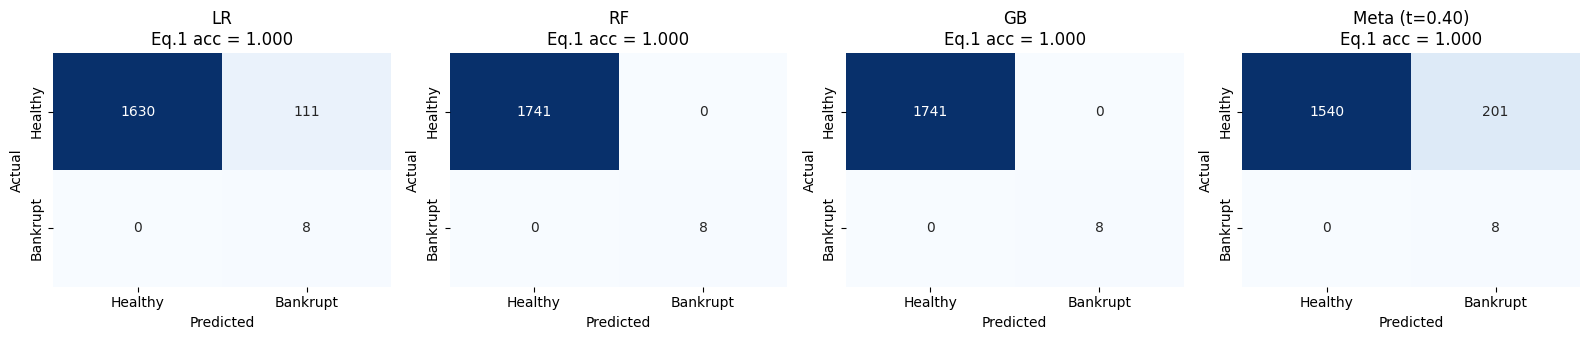

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
plots = [
    ('LR', fitted_bases['lr'].predict(X_selected)),
    ('RF', fitted_bases['rf'].predict(X_selected)),
    ('GB', fitted_bases['gb'].predict(X_selected)),
    (f'Meta (t={best_thresh:.2f})', y_pred_train),
]
for ax, (name, pred) in zip(axes, plots):
    cm = confusion_matrix(y, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Healthy', 'Bankrupt'], yticklabels=['Healthy', 'Bankrupt'])
    ax.set_title(f'{name}\nEq.1 acc = {eq1_accuracy(y, pred):.3f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [23]:
import os
have_test   = os.path.exists('test_data.csv')
have_router = os.path.exists('cluster_id_classifier.joblib')

if have_test and have_router:
    test_df  = pd.read_csv('test_data.csv')
    router   = joblib.load('cluster_id_classifier.joblib')
    
    test_features = test_df.drop(columns=['Index'])
    if ' Net Income Flag' in test_features.columns:
        test_features = test_features.drop(columns=[' Net Income Flag'])
    
    routed = router.predict(test_features)
    mask = (routed == 1)
    print(f'Test companies routed to C1: {mask.sum()}')
    
    if mask.sum() > 0:
        my_test = test_df.loc[mask].drop(columns=['Index'])
        preds = predict_with_bundle(model_bundle, my_test)
        print(f'Flagged as bankrupt: {preds.sum()} ({preds.mean()*100:.1f}%)')
        
        out = pd.DataFrame({'Index': test_df.loc[mask, 'Index'].values, 'Bankrupt?': preds})
        out.to_csv('aania_c1_test_predictions.csv', index=False)
        print('saved: aania_c1_test_predictions.csv')
else:
    print('Skipping — need test_data.csv and cluster_id_classifier.joblib in this folder')

Skipping — need test_data.csv and cluster_id_classifier.joblib in this folder


## For the team report

| Subgroup ID | Name | Companies | Bankrupt | TT | TF | N_features |
|---|---|---|---|---|---|---|
| 1 | Aania | 1749 | 8 | 8 | 0 | 6 |

Overall, Cluster 1 is difficult to model because it has only 8 bankrupt companies.

My main focus was:
- identifying as many bankrupt cases as possible
- keeping the model simple
- avoiding unnecessary feature complexity

Even though the model performs well on training data, there is a high chance of overfitting due to the small number of positive examples.